In [71]:
from mt import MT
import pandas as pd
import matplotlib.pyplot as plt
import time

Загрузка БД

In [10]:
def load_db(path: str) -> pd.DataFrame:
    return pd.read_csv(path, index_col="Index")

Детерминированный отбор пользователей

In [ ]:
def select_users(
    df: pd.DataFrame,
    seed: int,
    max_group_size: int,
    min_id: int,
    max_id: int,
):
    mt19937 = MT(seed)
    id_range = max_id - min_id + 1

    selected_ids = {
        min_id + (x % id_range)
        for x in mt19937.runif(max_group_size)
    }

    test_group = df[
        df.index.isin(selected_ids)
    ].copy()

    return test_group

Тесты

In [94]:
def test(path, seed, max_group_size, min_id, max_id):
    
    df = load_db(path)
    select_start_time = time.time()
    test_group = select_users(
        df,
        seed,
        max_group_size,
        min_id,
        max_id,
    )
    select_end_time = time.time()
    select_time = select_end_time - select_start_time
    print(f"Время отбора: {select_time:.4f} сек")

    plt.figure()
    test_group.index.to_series().hist(bins=50)
    plt.title(
        f"{path}\n"
        f"seed={seed} | requested={max_group_size} | real={test_group.shape[0]} | range=[{min_id}, {max_id}]"
    )
    plt.grid(False)

    plt.xlabel("Index")
    plt.ylabel("Count")
    plt.show()

Время отбора: 0.0016 сек


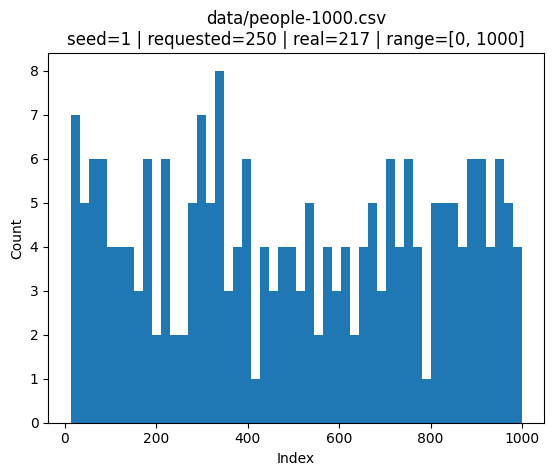

Время отбора: 0.0014 сек


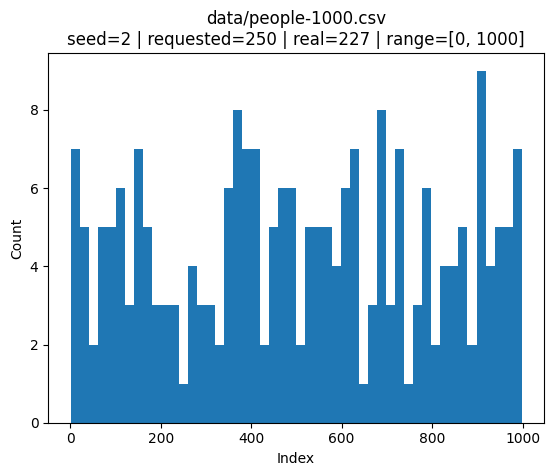

In [95]:
test("data/people-1000.csv", 1, 250, min_id=0, max_id=1000)
test("data/people-1000.csv", 2, 250, min_id=0, max_id=1000)

Время отбора: 0.0047 сек


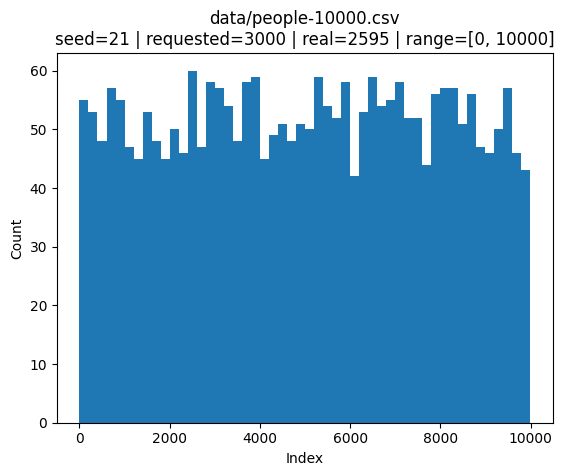

Время отбора: 0.0263 сек


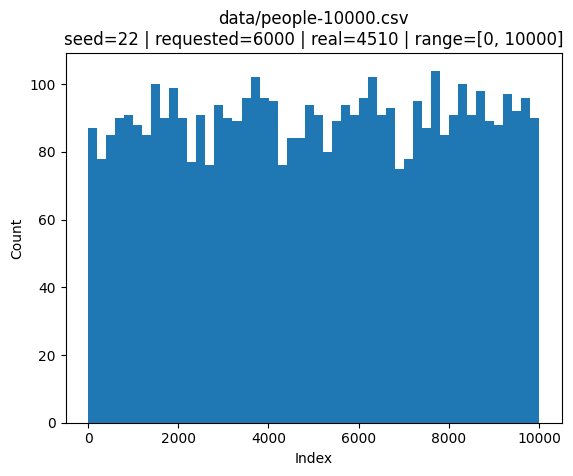

In [96]:
test("data/people-10000.csv", 21, 3000, 0, 10000)
test("data/people-10000.csv", 22, 6000, 0, 10000)


Время отбора: 0.0157 сек


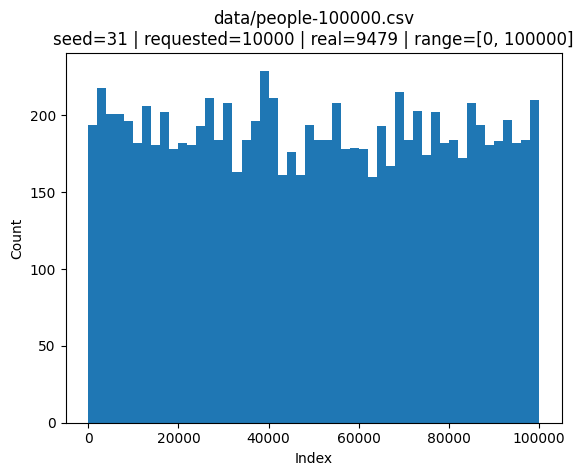

Время отбора: 0.0621 сек


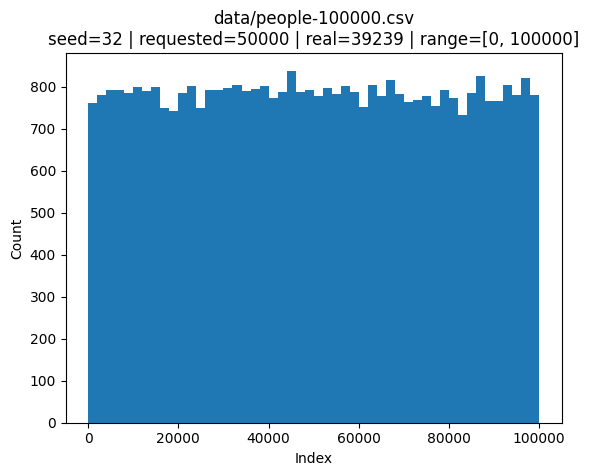

In [97]:
test("data/people-100000.csv", 31, 10000, 0, 100000)
test("data/people-100000.csv", 32, 50000, 0, 100000)
